In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14

df = pd.read_csv("donnees_consolidees.csv")
df = df.dropna(subset=["Base Severity", "Editeur", "Type"])


df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["CVSS"] = pd.to_numeric(df["CVSS"], errors="coerce")
df["EPSS"] = pd.to_numeric(df["EPSS"], errors="coerce")
df["Base Severity"] = df["Base Severity"].fillna("Inconnue")

print(f"✅ Données chargées avec succès : {df.shape[0]} lignes et {df.shape[1]} colonnes.")

✅ Données chargées avec succès : 722 lignes et 14 colonnes.


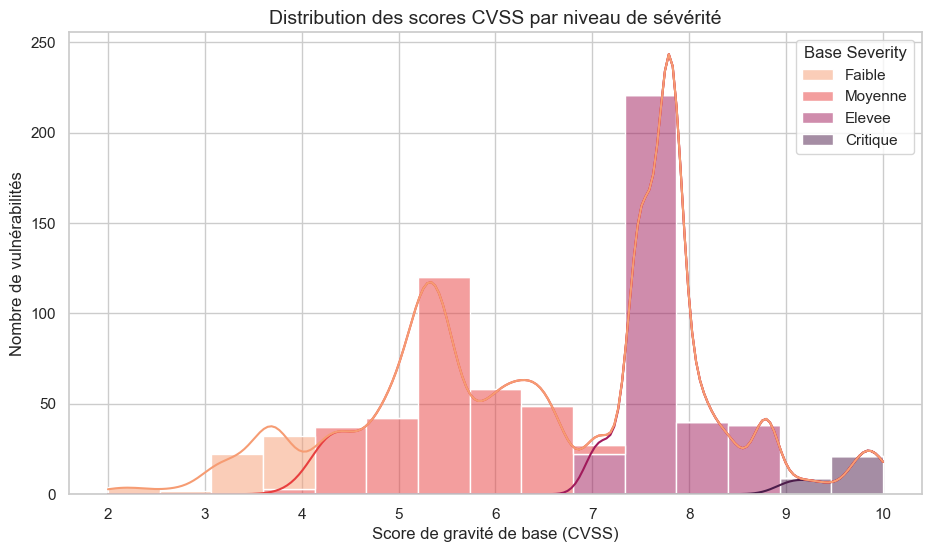

In [16]:
# --- Graphique 1 : Distribution des scores CVSS ---
plt.figure()
df_cvss = df.dropna(subset=["CVSS"])
order = ["Faible", "Moyenne", "Elevee", "Critique", "Inconnue"]
available_order = [s for s in order if s in df_cvss["Base Severity"].unique()]

sns.histplot(
    data=df_cvss, x="CVSS", hue="Base Severity", hue_order=available_order,
    multiple="stack", bins=15, kde=True, palette="rocket_r"
)
plt.title("Distribution des scores CVSS par niveau de sévérité")
plt.xlabel("Score de gravité de base (CVSS)")
plt.ylabel("Nombre de vulnérabilités")
plt.show()



L’analyse de la sévérité globale des vulnérabilités montre une surreprésentation des niveaux de criticité élevés. Les failles qualifiées d'Élevée constituent la majeure partie du jeu de données avec 873 occurrences, suivies par les failles Critiques (240) et Moyennes (239), tandis que les vulnérabilités Faibles restent marginales (11).
Cette répartition démontre que le flux de publication du CERT-FR (ANSSI) se concentre quasi exclusivement sur des menaces à fort impact potentiel. Pour les équipes de sécurité, cela souligne la nécessité d'une veille active, car près de 78 % des alertes reçues concernent des vulnérabilités capables de compromettre gravement l'intégrité d'un système d'information.

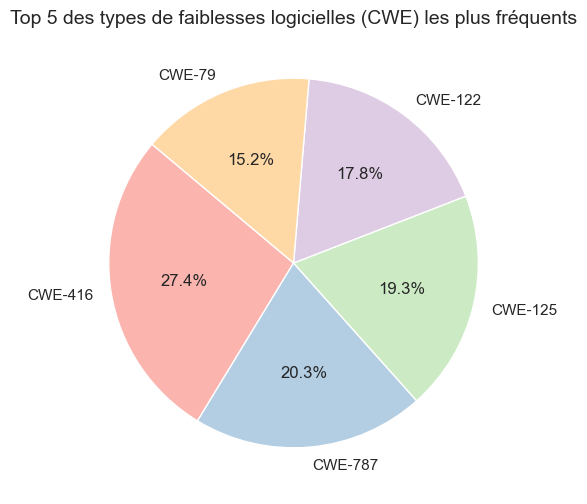

In [7]:
# --- Graphique 2 : Diagramme circulaire des CWE (Top 5) ---
plt.figure()
df_cwe = df.dropna(subset=["CWE"])
if not df_cwe.empty:
    top_cwe = df_cwe["CWE"].value_counts().head(5)
    plt.pie(
        top_cwe, labels=top_cwe.index, autopct="%1.1f%%", 
        startangle=140, colors=sns.color_palette("Pastel1")
    )
    plt.title("Top 5 des types de faiblesses logicielles (CWE) les plus fréquents")
    plt.show()
else:
    print("⚠️ Aucune donnée CWE disponible pour le diagramme circulaire.")

Ce graphique en camembert illustre le Top 5 des types de faiblesses logicielles (CWE) les plus fréquemment rencontrées.
CWE-416 (Use After Free) représente 27,4 % des faiblesses.
C’est la vulnérabilité la plus courante. Elle se produit lorsqu’un programme continue d’utiliser un pointeur vers une zone de mémoire qui a déjà été libérée. Cela peut permettre à un attaquant de prendre le contrôle du programme.
CWE-787 (Out-of-bounds Write) arrive en deuxième position avec 20,3 %.
Cette faille survient quand un programme écrit des données en dehors des limites d’un tampon (buffer) alloué en mémoire. C’est une vulnérabilité très dangereuse car elle permet souvent l’exécution de code arbitraire.
CWE-125 (Out-of-bounds Read) représente 19,3 %.
Elle se produit lorsqu’un programme lit des données en dehors des limites d’un tampon. Cela peut mener à des fuites d’informations sensibles (comme des mots de passe ou des clés) ou être utilisé pour contourner des mécanismes de sécurité.
CWE-122 (Heap-based Buffer Overflow) correspond à 17,8 %.
Il s’agit d’un débordement de tampon sur le tas (heap). Un attaquant peut écraser des données importantes en mémoire, ce qui est souvent exploité pour détourner le flux d’exécution du programme.
CWE-79 (Cross-site Scripting ou XSS) ferme le classement avec 15,2 %.
Cette vulnérabilité web permet à un attaquant d’injecter du code JavaScript malveillant dans une page vue par d’autres utilisateurs. Elle est très répandue dans les applications web et peut servir à voler des sessions, afficher du contenu frauduleux ou rediriger les utilisateurs.
Les quatre premières faiblesses (CWE-416, 787, 125 et 122) sont principalement des problèmes de gestion mémoire en langages bas niveau comme le C et le C++. Elles représentent plus de 84 % du top 5. Cela montre que les erreurs liées à la manipulation directe de la mémoire restent le plus grand risque en matière de sécurité logicielle aujourd’hui.

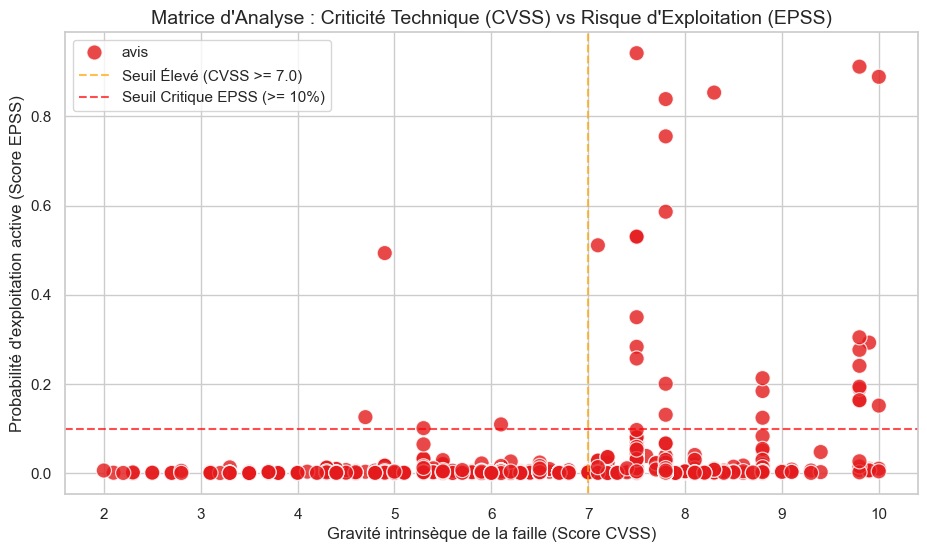

In [8]:
# --- Graphique 3 : Nuage de points CVSS vs EPSS  ---
plt.figure()
df_scatter = df.dropna(subset=["CVSS", "EPSS"])

sns.scatterplot(
    data=df_scatter, x="CVSS", y="EPSS", hue="Type", 
    style="Type", s=120, alpha=0.8, palette="Set1"
)

plt.axvline(x=7.0, color="orange", linestyle="--", alpha=0.7, label="Seuil Élevé (CVSS >= 7.0)")
plt.axhline(y=0.10, color="red", linestyle="--", alpha=0.7, label="Seuil Critique EPSS (>= 10%)")

plt.title("Matrice d'Analyse : Criticité Technique (CVSS) vs Risque d'Exploitation (EPSS)")
plt.xlabel("Gravité intrinsèque de la faille (Score CVSS)")
plt.ylabel("Probabilité d'exploitation active (Score EPSS)")
plt.legend(loc="upper left")
plt.show()

Ce graphique représente une matrice d’analyse croisée entre la gravité intrinsèque des vulnérabilités (CVSS) et leur probabilité réelle d’exploitation (EPSS). L’objectif est de dépasser une lecture uniquement technique des vulnérabilités pour intégrer une dimension plus opérationnelle : une vulnérabilité très grave n’est pas forcément exploitée dans la réalité, tandis qu’une vulnérabilité moins critique peut représenter un risque immédiat si elle est activement exploitée.

Zone 1 :
avec un CVSS inférieur à 7 et une probabilité EPSS inférieure à 10 % : on remarque qu’un nombre important de points se concentre ici.Cela signifie que la majorité des vulnérabilités observées sont techniquement peu ou moyennement graves / peu susceptibles d’être exploitées activement.
Ces vulnérabilités restent à surveiller mais ne constituent généralement pas une priorité immédiate de remédiation.

Zone 2 : 
Cette zone est particulièrement intéressante car elle montre que certaines vulnérabilités jugées modérément graves techniquement peuvent malgré tout être fortement ciblées par les attaquants. Cela rappelle qu’un score CVSS seul ne suffit pas pour définir les priorités.
Une faille peu spectaculaire techniquement peut devenir critique si elle est simple à exploiter / un exploit est disponible publiquement / elle concerne des systèmes largement déployés.

Zone 3 : 
On y trouve de nombreuses vulnérabilités avec un CVSS supérieur à 7 mais un EPSS proche de 0. Cela montre qu’un grand nombre de vulnérabilités considérées comme sévères sur le plan technique ne sont pas activement exploitées dans les faits. Plusieurs explications peuvent exister : exploitation complexe ; conditions d’attaque difficiles ; faible diffusion des systèmes concernés ; absence d’outils d’exploitation publics.

Zone 4 : 
On observe plusieurs points concentrés entre CVSS ≈ 7 et 10 avec des EPSS parfois supérieurs à 80–90 %. Ces vulnérabilités cumulent un impact technique important et une forte probabilité d’exploitation réelle.
Ce sont les vulnérabilités qui devraient être traitées en priorité absolue dans une stratégie de gestion des correctifs.
La présence de plusieurs points proches de CVSS = 10 et EPSS > 0,8 indique qu’il existe des vulnérabilités à la fois extrêmement critiques et très attractives pour les attaquants.

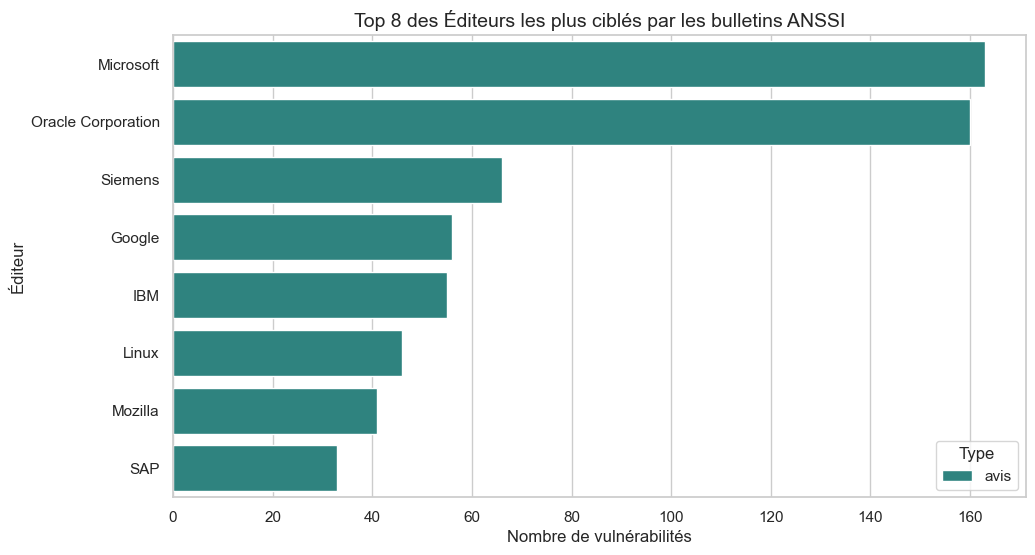

In [12]:
# --- Graphique 4 : Classement des Éditeurs les plus touchés ---
df_vendor = df.dropna(subset=["Editeur"])
if not df_vendor.empty:
    top_vendors = df_vendor["Editeur"].value_counts().head(8).index
    
    plt.figure()
    sns.countplot(
        data=df_vendor[df_vendor["Editeur"].isin(top_vendors)],
        y="Editeur", hue="Type", order=top_vendors, palette="viridis"
    )
    plt.title("Top 8 des Éditeurs les plus ciblés par les bulletins ANSSI")
    plt.xlabel("Nombre de vulnérabilités")
    plt.ylabel("Éditeur")
    plt.show()

 


Le classement des éditeurs met en évidence une concentration majeure des vulnérabilités chez les leaders du marché technologique. Microsoft domine largement ce top, suivi par Oracle, Siemens et Google.
Cette forte présence de Microsoft ne traduit pas un manque inhérent de sécurité, mais illustre un biais de surface d'attaque : ce système étant les plu déployé mondialement en entreprise, il fait l'objet d'audits et de recherches de failles permanents par la communauté de la cybersécurité. Les attaquants ciblent en priorité cet environnement en raison de son immense retour sur investissement potentiel.

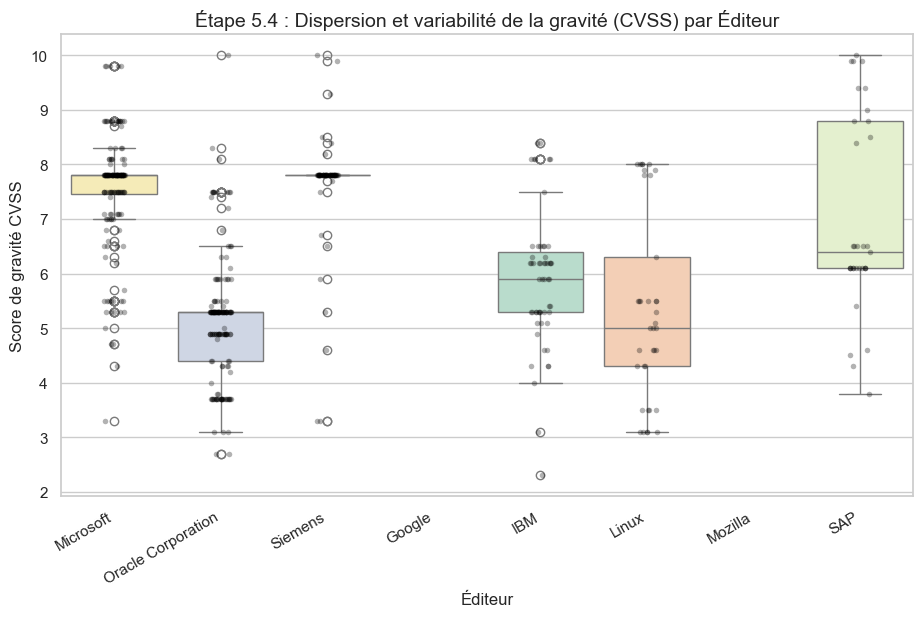

In [10]:
# --- Graphique 5 : Boxplot de dispersion CVSS par Éditeur ---
plt.figure()

df_vendor = df.dropna(subset=["Editeur"])
top_vendors = df_vendor["Editeur"].value_counts().head(8).index
df_top_v = df_vendor[df_vendor["Editeur"].isin(top_vendors)].dropna(subset=["CVSS"])

sns.boxplot(
    data=df_top_v, x="Editeur", y="CVSS", 
    hue="Editeur", palette="Pastel2", order=top_vendors, legend=False
)

sns.stripplot(
    data=df_top_v, x="Editeur", y="CVSS", 
    color="black", alpha=0.3, size=4, order=top_vendors
)
plt.title("Étape 5.4 : Dispersion et variabilité de la gravité (CVSS) par Éditeur")
plt.xticks(rotation=30, ha="right")
plt.xlabel("Éditeur")
plt.ylabel("Score de gravité CVSS")
plt.show()

Le graphique présenté est un diagramme en boîte (boxplot) qui permet d’analyser la répartition des scores CVSS des vulnérabilités en fonction de chaque éditeur. Le score CVSS (Common Vulnerability Scoring System) mesure la gravité d’une vulnérabilité sur une échelle allant généralement de 0 (faible gravité) à 10 (gravité critique). L’objectif de ce graphique est de comparer non seulement le niveau moyen de gravité, mais aussi la variabilité des vulnérabilités entre différents éditeurs.

On observe que la gravité des vulnérabilités varie selon les éditeurs.
Microsoft présente une médiane élevée (≈ 7,7) avec une boîte assez étroite : cela suggère que les vulnérabilités ont souvent un niveau de gravité élevé mais relativement homogène.
Oracle Corporation affiche une médiane plus faible (≈ 5) et une dispersion modérée : les vulnérabilités semblent globalement moins sévères, même si certaines atteignent des niveaux critiques.
Siemens possède une médiane élevée (≈ 7,8) avec plusieurs valeurs proches de 10, indiquant la présence de vulnérabilités parfois très critiques.
IBM montre une gravité moyenne (≈ 6) et une dispersion intermédiaire : les scores restent relativement concentrés.
Linux présente une dispersion importante, avec des scores allant d’environ 3 à 8, ce qui traduit une forte variabilité des vulnérabilités.
SAP est l’éditeur qui semble avoir la plus forte variabilité : les scores s’étendent sur presque toute l’échelle (≈ 4 à 10), ce qui indique que ses vulnérabilités peuvent être aussi bien modérées que très critiques.

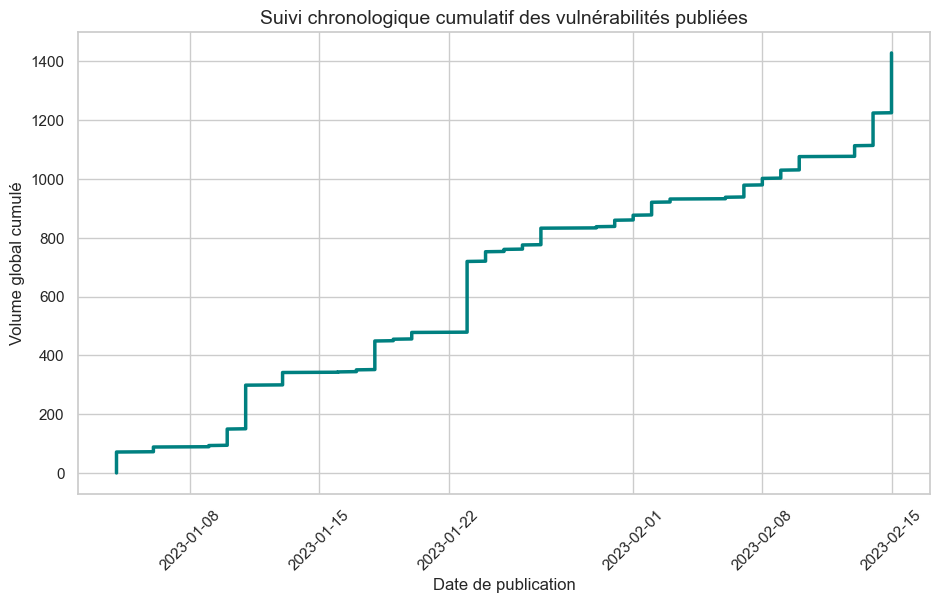

In [11]:
# --- Graphique 6 : Évolution Temporelle Cumulative ---
plt.figure()
df_time = df.dropna(subset=["Date"]).sort_values("Date")
if not df_time.empty:
    df_time["Nombre Cumulé"] = range(1, len(df_time) + 1)
    plt.plot(df_time["Date"], df_time["Nombre Cumulé"], color="teal", linewidth=2.5)
    plt.title("Suivi chronologique cumulatif des vulnérabilités publiées")
    plt.xlabel("Date de publication")
    plt.ylabel("Volume global cumulé")
    plt.xticks(rotation=45)
    plt.show()

La courbe commence très bas début janvier (autour de 50 vulnérabilités). Elle augmente ensuite de manière progressive mais irrégulière, avec plusieurs paliers et hausses brutales : Une première forte augmentation se produit autour du 22 janvier, où le cumul passe rapidement de ~450 à plus de 700 vulnérabilités.
La courbe continue de monter régulièrement tout au long du mois de janvier et début février.
Une très forte accélération est visible vers la mi-février (autour du 12-15 février), où le volume cumulé passe de ~1 100 à plus de 1 400 vulnérabilités en très peu de temps.
Sur cette période d’environ 5 semaines, plus de 1 400 vulnérabilités ont été publiées. 
On observe une croissance globale soutenue, avec des pics d’activité importants, notamment fin janvier et surtout mi-février. Cela indique une publication assez régulière de failles de sécurité, avec des périodes de forte activité (probablement liées à des campagnes de divulgation ou des mises à jour massives de logiciels).

In [2]:
print(df.shape)

(1427, 14)


In [ ]:
### Modèles de machine learning ###

Création de modèles de machine learning.

Nous avons choisi de créer plusieurs modèles de machine learning afin de pouvoir les comparer entre eux et de choisir les modèles les plus performants pour chaque catégorie (supervisé et non-supervisé).

- Modèles supervisés : Random Forest, Gradient Boosting, SVC et K-NN

- Modèles non-supervisés : K-Means, Isolation Forest, et PCA

✅ Données synchronisées pour l'IA : 810 lignes prêtes.
  Train : 648 | Test : 162
  Distribution cible : {'Faible': np.int64(67), 'Moyenne': np.int64(357), 'Elevee': np.int64(356), 'Critique': np.int64(30)}


──────────────────────────────────────────────────
  ► Random Forest
──────────────────────────────────────────────────
  Accuracy  : 0.994
  F1-macro  : 0.989
  CV F1-macro (5-fold) : 0.991 ± 0.018


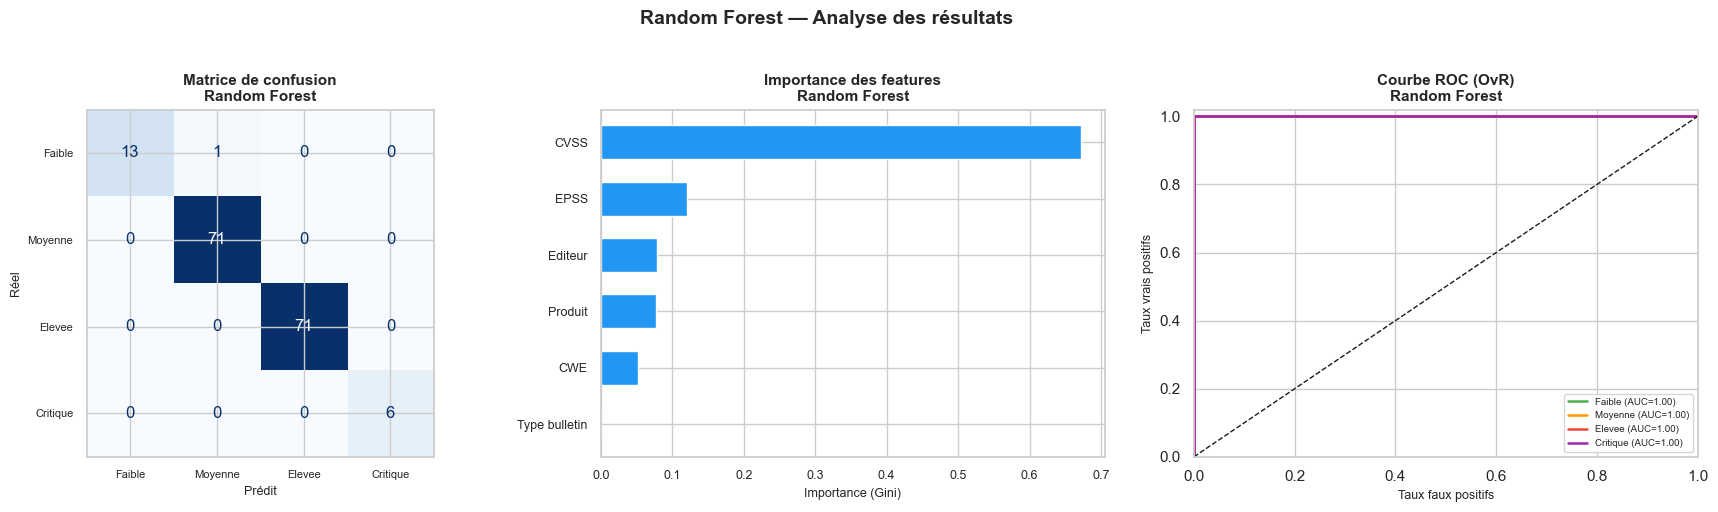

  → Graphique sauvegardé : rf_results.png

──────────────────────────────────────────────────
  ► Gradient Boosting
──────────────────────────────────────────────────
  Accuracy  : 1.000
  F1-macro  : 1.000
  CV F1-macro (5-fold) : 1.000 ± 0.000


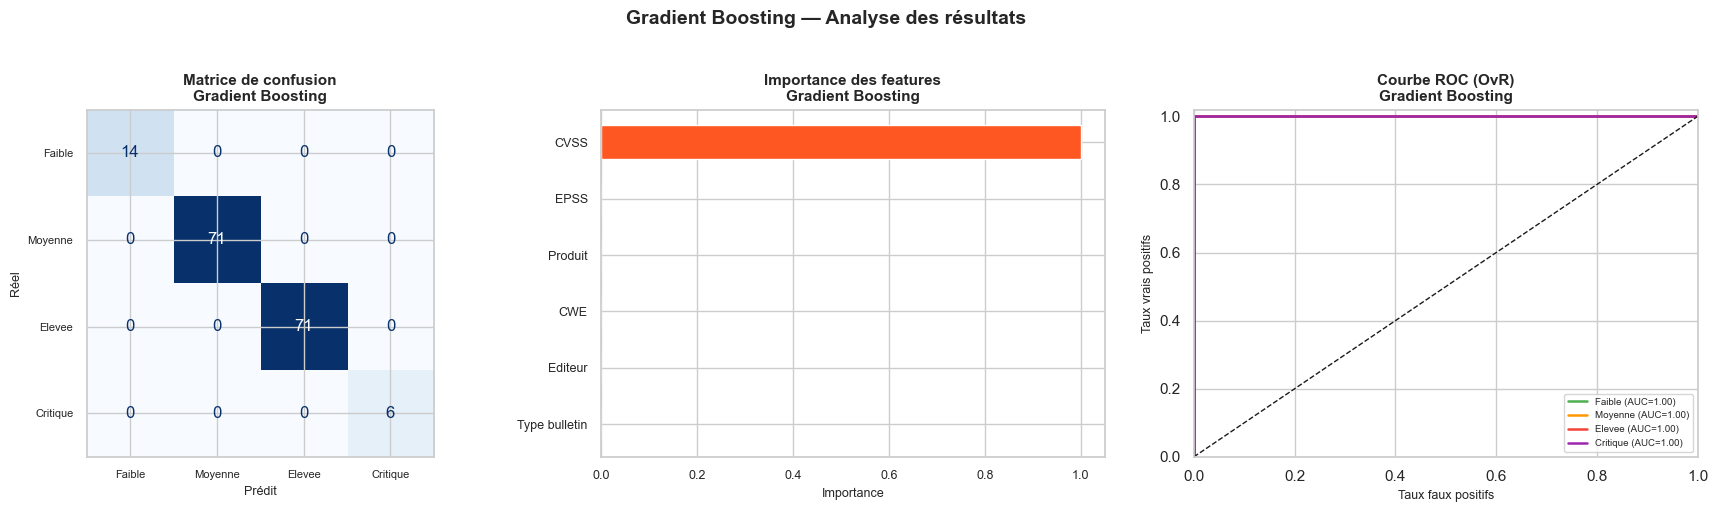

  → Graphique sauvegardé : gb_results.png

──────────────────────────────────────────────────
  ► SVM (RBF)
──────────────────────────────────────────────────
  Accuracy  : 0.981
  F1-macro  : 0.962
  CV F1-macro (5-fold) : 0.931 ± 0.011


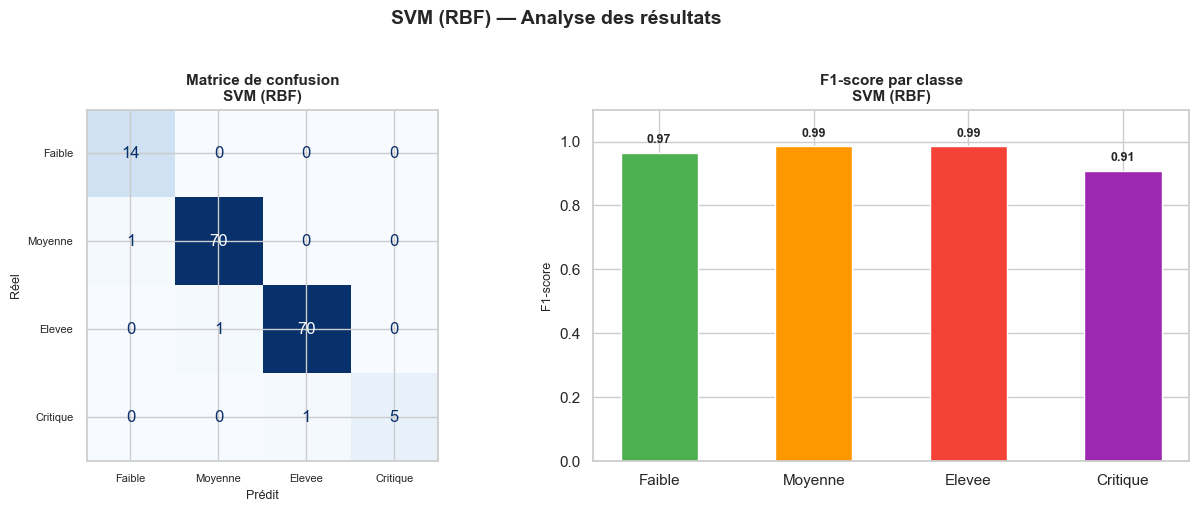

  → Graphique sauvegardé : svm_results.png
  Meilleur k trouvé : 1 (F1-macro CV = 0.886)

──────────────────────────────────────────────────
  ► KNN (k=1)
──────────────────────────────────────────────────
  Accuracy  : 0.969
  F1-macro  : 0.922
  CV F1-macro (5-fold) : 0.886 ± 0.039


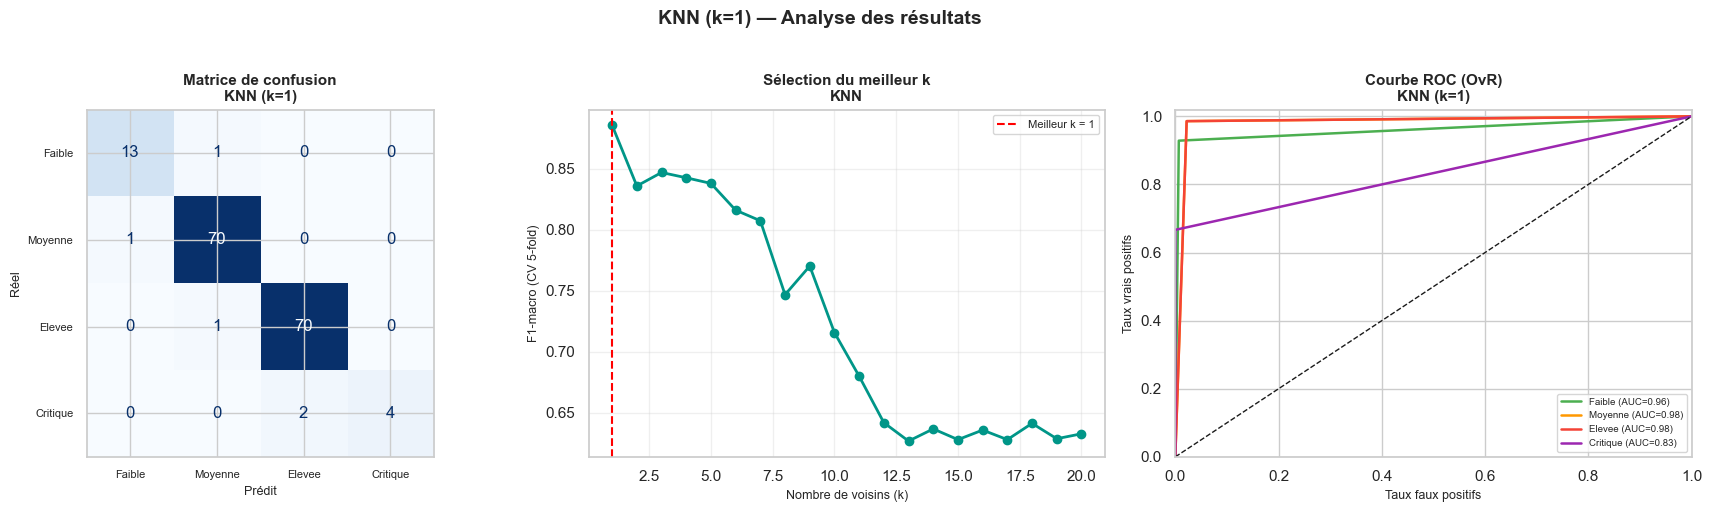

  → Graphique sauvegardé : knn_results.png
                   Accuracy  F1-macro  Précision  Rappel
Random Forest         0.994     0.989      0.997   0.982
Gradient Boosting     1.000     1.000      1.000   1.000
SVM (RBF)             0.981     0.962      0.976   0.951
KNN (k=1)             0.969     0.922      0.968   0.892


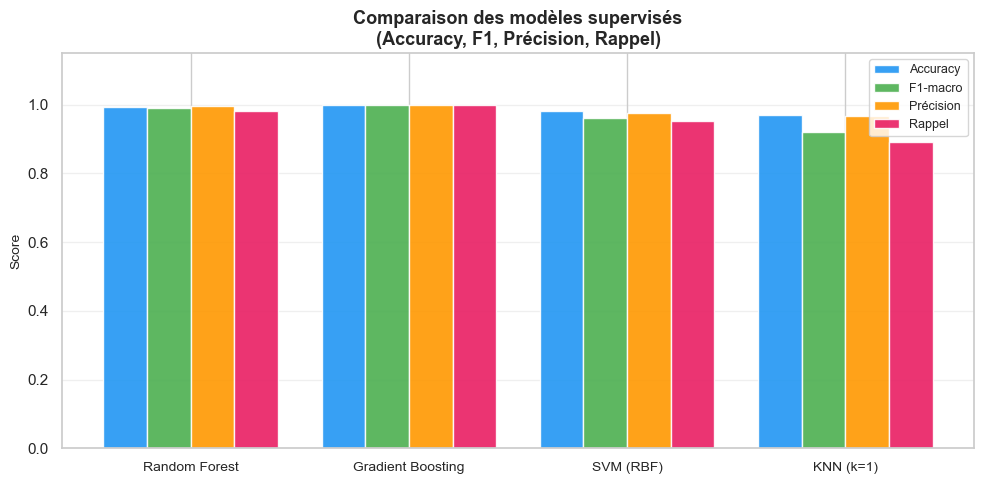

  → Graphique sauvegardé : comparaison_supervisee.png
  Composantes pour 95% de variance expliquée : 5
  Variance expliquée PCA 2D : 55.0%


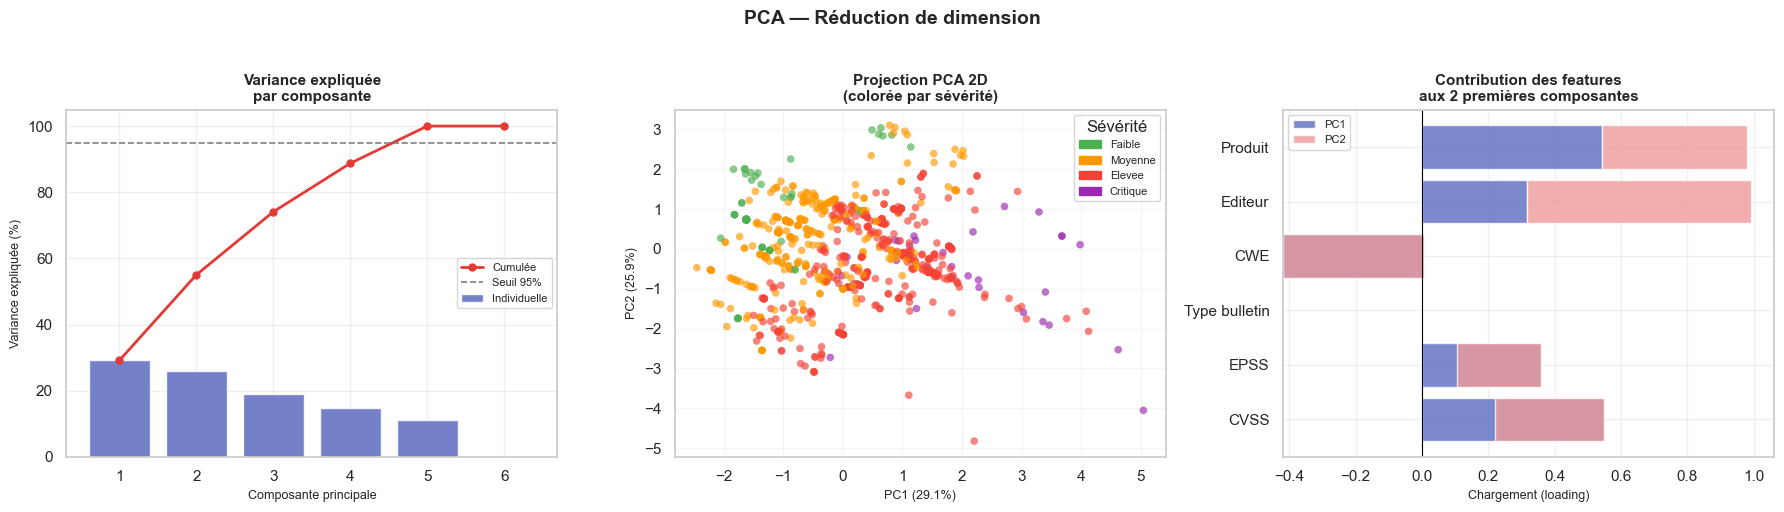

  → Graphique sauvegardé : pca_results.png
  Meilleur k (silhouette) : 10
  Distribution des clusters :
    Cluster 0 : 65 CVEs (8.0%)
    Cluster 1 : 200 CVEs (24.7%)
    Cluster 2 : 108 CVEs (13.3%)
    Cluster 3 : 62 CVEs (7.7%)
    Cluster 4 : 11 CVEs (1.4%)
    Cluster 5 : 87 CVEs (10.7%)
    Cluster 6 : 34 CVEs (4.2%)
    Cluster 7 : 58 CVEs (7.2%)
    Cluster 8 : 103 CVEs (12.7%)
    Cluster 9 : 82 CVEs (10.1%)

  Profil moyen par cluster :
            CVSS  EPSS Base Severity  Type
km_cluster                                
0           4.76  0.01       Moyenne  avis
1           4.86  0.00       Moyenne  avis
2           8.04  0.03        Elevee  avis
3           7.26  0.01        Elevee  avis
4           7.82  0.71        Elevee  avis
5           7.81  0.01        Elevee  avis
6           5.40  0.01       Moyenne  avis
7           6.62  0.01       Moyenne  avis
8           7.62  0.01        Elevee  avis
9           6.74  0.00       Moyenne  avis


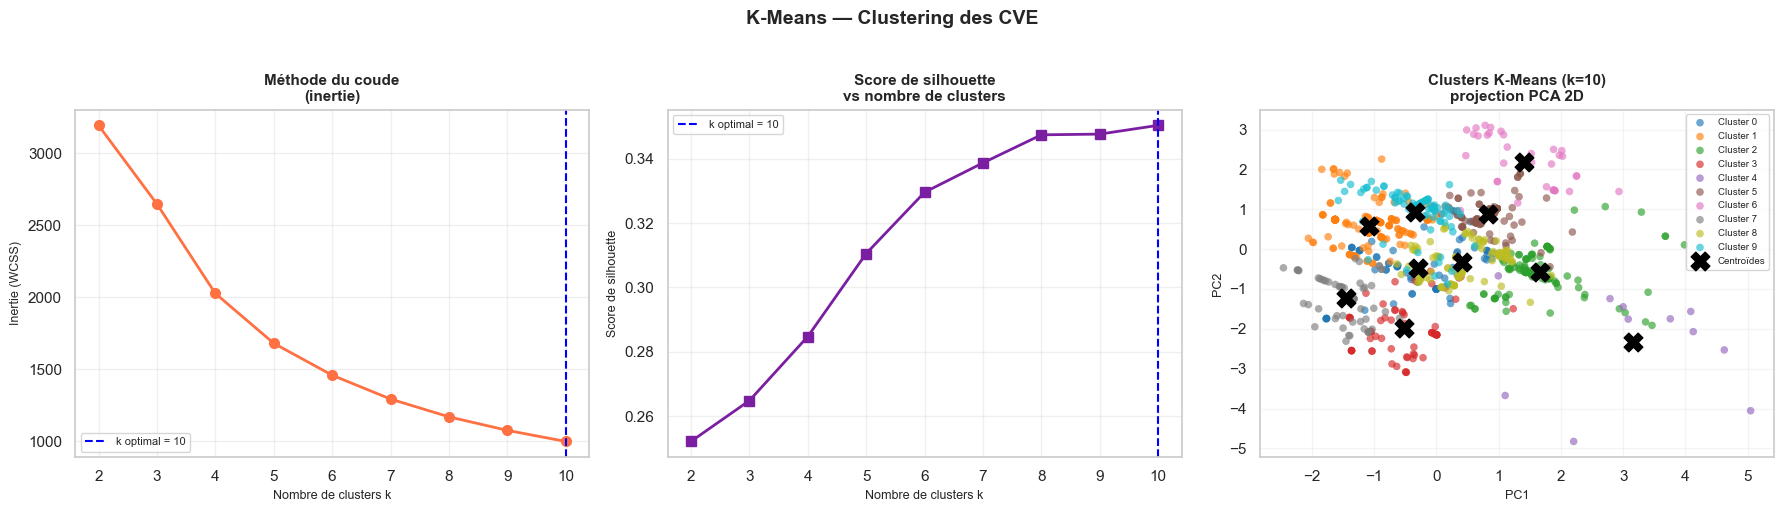

  → Graphique sauvegardé : kmeans_results.png
  CVEs détectées comme anomalies : 41 (5.1%)

  Aperçu des CVEs anormales :
           CVE  CVSS    EPSS Base Severity   Editeur                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          Produit
CVE-2022-43931  10.0 0.15154      Critique  Synology                                                                                                                    

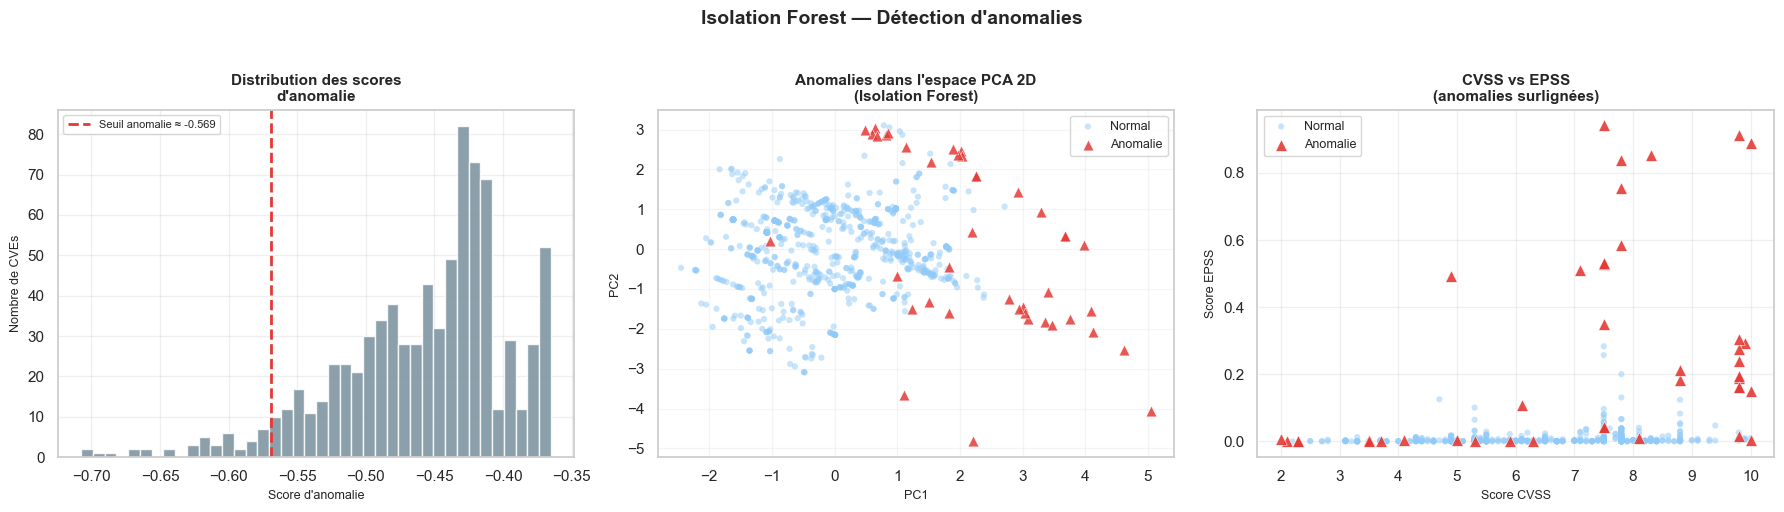

  → Graphique sauvegardé : isolation_forest_results.png

  RÉSUMÉ FINAL

  MODÈLES SUPERVISÉS
                  Accuracy F1-macro Précision Rappel
Random Forest        0.994    0.989     0.997  0.982
Gradient Boosting    1.000    1.000     1.000  1.000
SVM (RBF)            0.981    0.962     0.976  0.951
KNN (k=1)            0.969    0.922     0.968  0.892

  MODÈLES NON SUPERVISÉS
  PCA           → 5 composantes nécessaires pour 95% de variance
  K-Means       → 10 clusters optimaux (silhouette)
  Isolation Forest → 41 anomalies détectées (5.1%)


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)

# Supervised -----------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Unsupervised ---------------------------------
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA



# ═════════════════════════════════════════════════════════════════════════════════════════════════════
# CHARGEMENT ET PRÉPARATION DES DONNÉES (VERSION FUSIONNÉE PROPRE)
# ═════════════════════════════════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. NETTOYAGE : On filtre la table existante pour enlever les "Inconnue" et les NaN pour l'IA
df = df.dropna(subset=["Base Severity", "CVSS", "EPSS"]).copy()
df = df[df["Base Severity"] != "Inconnue"]

print(f"✅ Données synchronisées pour l'IA : {len(df)} lignes prêtes.")

# 2. ENCODAGES
# Encodage de la cible en chiffres (0, 1, 2, 3) pour éviter l'erreur bincount
severity_order = {"Faible": 0, "Moyenne": 1, "Elevee": 2, "Critique": 3}
df["severity_encoded"] = df["Base Severity"].map(severity_order)

# Encodage du type de bulletin (avis=0 / alerte=1)
df["type_encoded"] = (df["Type"] == "alerte").astype(int)

# Encodage des colonnes de texte en chiffres (Label Encoding)
le_cwe = LabelEncoder()
le_editeur = LabelEncoder()
le_produit = LabelEncoder()
df["cwe_encoded"] = le_cwe.fit_transform(df["CWE"].fillna("Unknown"))
df["editeur_encoded"] = le_editeur.fit_transform(df["Editeur"].fillna("Unknown"))
df["produit_encoded"] = le_produit.fit_transform(df["Produit"].fillna("Unknown"))

# 3. SELECTION DES 6 FEATURES ATTENDUES PAR LES MODÈLES
FEATURES_NUM = ["CVSS", "EPSS", "type_encoded", "cwe_encoded", "editeur_encoded", "produit_encoded"]
TARGET = "severity_encoded"

X_num = df[FEATURES_NUM].values
y = df[TARGET].values

# 4. NORMALISATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# 5. SPLIT TRAIN / TEST PROPRE ET SYNCHRONISÉ
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42, stratify=y
)
X_train_sc, X_test_sc = (
    scaler.fit_transform(X_train_raw),
    scaler.transform(X_test_raw),
)

class_names = ["Faible", "Moyenne", "Elevee", "Critique"]
n_classes   = len(class_names)
colors_cls  = ["#4CAF50", "#FF9800", "#F44336", "#9C27B0"]

print(f"  Train : {len(y_train)} | Test : {len(y_test)}")
print(f"  Distribution cible : {dict(zip(class_names, np.bincount(y)))}\n")

# 3 fonctions pour aider à l'évalutation des modèles----------------------------------------------------

def plot_confusion(cm, model_name, ax):
    """Affiche une matrice de confusion stylisée sur un axe donné."""
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Matrice de confusion\n{model_name}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Prédit", fontsize=9)
    ax.set_ylabel("Réel", fontsize=9)
    ax.tick_params(labelsize=8)


def multiclass_roc(y_true, y_score, model_name, ax):
    """ROC OvR pour classification multiclasse."""
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    for i, (cls, col) in enumerate(zip(class_names, colors_cls)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=1.8, label=f"{cls} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("Taux faux positifs", fontsize=9)
    ax.set_ylabel("Taux vrais positifs", fontsize=9)
    ax.set_title(f"Courbe ROC (OvR)\n{model_name}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=7, loc="lower right")


def evaluate_model(name, clf, X_tr, X_te, y_tr, y_te, use_proba=True):
    """Entraîne, évalue et retourne métriques + prédictions."""
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    cm     = confusion_matrix(y_te, y_pred)
    report = classification_report(y_te, y_pred, target_names=class_names, output_dict=True)
    if use_proba and hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_te)
    elif hasattr(clf, "decision_function"):
        raw     = clf.decision_function(X_te)
        # softmax pour normaliser
        e_x     = np.exp(raw - raw.max(axis=1, keepdims=True))
        y_score = e_x / e_x.sum(axis=1, keepdims=True)
    else:
        y_score = None
    cv_scores = cross_val_score(clf, X_tr, y_tr, cv=StratifiedKFold(5), scoring="f1_macro")
    print(f"\n{'─'*50}")
    print(f"  ► {name}")
    print(f"{'─'*50}")
    print(f"  Accuracy  : {report['accuracy']:.3f}")
    print(f"  F1-macro  : {report['macro avg']['f1-score']:.3f}")
    print(f"  CV F1-macro (5-fold) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    return clf, y_pred, y_score, cm, report



# RANDOM FOREST -------------------------------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_clf, rf_pred, rf_score, rf_cm, rf_report = evaluate_model(
    "Random Forest", rf, X_train_raw, X_test_raw, y_train, y_test
)

fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Random Forest — Analyse des résultats", fontsize=14, fontweight="bold", y=1.02)

# Matrice de confusion
plot_confusion(rf_cm, "Random Forest", axes[0])

# Importance des features
importances = rf_clf.feature_importances_
feat_names  = ["CVSS", "EPSS", "Type bulletin", "CWE", "Editeur", "Produit"]
idx_sorted  = np.argsort(importances)[::-1]
axes[1].barh(
    [feat_names[i] for i in idx_sorted[::-1]],
    importances[idx_sorted[::-1]],
    color="#2196F3", edgecolor="white", height=0.6
)
axes[1].set_xlabel("Importance (Gini)", fontsize=9)
axes[1].set_title("Importance des features\nRandom Forest", fontsize=11, fontweight="bold")
axes[1].tick_params(labelsize=9)

# Courbe ROC
multiclass_roc(y_test, rf_score, "Random Forest", axes[2])

plt.tight_layout()
plt.savefig("rf_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  → Graphique sauvegardé : rf_results.png")


# GRADIENT BOOSTING ------------------------------------------------------------------------------------

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=42,
)
gb_clf, gb_pred, gb_score, gb_cm, gb_report = evaluate_model(
    "Gradient Boosting", gb, X_train_raw, X_test_raw, y_train, y_test
)

fig2, axes = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Gradient Boosting — Analyse des résultats", fontsize=14, fontweight="bold", y=1.02)

plot_confusion(gb_cm, "Gradient Boosting", axes[0])

gb_importances = gb_clf.feature_importances_
idx_sorted_gb  = np.argsort(gb_importances)[::-1]
axes[1].barh(
    [feat_names[i] for i in idx_sorted_gb[::-1]],
    gb_importances[idx_sorted_gb[::-1]],
    color="#FF5722", edgecolor="white", height=0.6
)
axes[1].set_xlabel("Importance", fontsize=9)
axes[1].set_title("Importance des features\nGradient Boosting", fontsize=11, fontweight="bold")
axes[1].tick_params(labelsize=9)

multiclass_roc(y_test, gb_score, "Gradient Boosting", axes[2])

plt.tight_layout()
plt.savefig("gb_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  → Graphique sauvegardé : gb_results.png")



# SVM --------------------------------------------------------------------------------------------------

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    decision_function_shape="ovr",
    random_state=42,
)
svm_clf, svm_pred, svm_score, svm_cm, svm_report = evaluate_model(
    "SVM (RBF)", svm, X_train_sc, X_test_sc, y_train, y_test, use_proba=False
)

fig3, axes = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle("SVM (RBF) — Analyse des résultats", fontsize=14, fontweight="bold", y=1.02)

plot_confusion(svm_cm, "SVM (RBF)", axes[0])

# F1 par classe (barchart à la place de ROC car pas de probabilités)
f1_per_class = [svm_report[cls]["f1-score"] for cls in class_names]
bars = axes[1].bar(class_names, f1_per_class, color=colors_cls, edgecolor="white", width=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("F1-score", fontsize=9)
axes[1].set_title("F1-score par classe\nSVM (RBF)", fontsize=11, fontweight="bold")
for bar, val in zip(bars, f1_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("svm_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  → Graphique sauvegardé : svm_results.png")



# K-NEAREST NEIGHBORS ---------------------------------------------------------------------------------

# Choix optimal de k via validation croisée
k_range   = range(1, 21)
cv_f1_knn = []
for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    scores  = cross_val_score(knn_tmp, X_train_sc, y_train,
                               cv=StratifiedKFold(5), scoring="f1_macro")
    cv_f1_knn.append(scores.mean())

best_k = k_range[np.argmax(cv_f1_knn)]
print(f"  Meilleur k trouvé : {best_k} (F1-macro CV = {max(cv_f1_knn):.3f})")

knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
knn_clf, knn_pred, knn_score, knn_cm, knn_report = evaluate_model(
    f"KNN (k={best_k})", knn, X_train_sc, X_test_sc, y_train, y_test
)

fig4, axes = plt.subplots(1, 3, figsize=(18, 5))
fig4.suptitle(f"KNN (k={best_k}) — Analyse des résultats", fontsize=14, fontweight="bold", y=1.02)

plot_confusion(knn_cm, f"KNN (k={best_k})", axes[0])

axes[1].plot(list(k_range), cv_f1_knn, marker="o", color="#009688",
             linewidth=2, markersize=6)
axes[1].axvline(x=best_k, color="red", linestyle="--", linewidth=1.5,
                label=f"Meilleur k = {best_k}")
axes[1].set_xlabel("Nombre de voisins (k)", fontsize=9)
axes[1].set_ylabel("F1-macro (CV 5-fold)", fontsize=9)
axes[1].set_title("Sélection du meilleur k\nKNN", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

multiclass_roc(y_test, knn_score, f"KNN (k={best_k})", axes[2])

plt.tight_layout()
plt.savefig("knn_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  → Graphique sauvegardé : knn_results.png")



# COMPARAISON GLOBALE DES MODÈLES SUPERVISÉS

models_summary = {
    "Random Forest":     rf_report,
    "Gradient Boosting": gb_report,
    "SVM (RBF)":         svm_report,
    f"KNN (k={best_k})": knn_report,
}

metrics_df = pd.DataFrame({
    name: {
        "Accuracy":   rep["accuracy"],
        "F1-macro":   rep["macro avg"]["f1-score"],
        "Précision":  rep["macro avg"]["precision"],
        "Rappel":     rep["macro avg"]["recall"],
    }
    for name, rep in models_summary.items()
}).T

print(metrics_df.round(3).to_string())

fig5, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(metrics_df))
width = 0.2
metric_cols  = ["Accuracy", "F1-macro", "Précision", "Rappel"]
metric_colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
for i, (col, col_color) in enumerate(zip(metric_cols, metric_colors)):
    ax.bar(x + i * width, metrics_df[col], width, label=col,
           color=col_color, edgecolor="white", alpha=0.9)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df.index, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("Comparaison des modèles supervisés\n(Accuracy, F1, Précision, Rappel)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparaison_supervisee.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  → Graphique sauvegardé : comparaison_supervisee.png")



# PCA (réduction de dimension + visualisation) ---------------------------------------------------------

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_comp_95 = np.argmax(cumulative >= 0.95) + 1
print(f"  Composantes pour 95% de variance expliquée : {n_comp_95}")

pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_scaled)
print(f"  Variance expliquée PCA 2D : {pca_2d.explained_variance_ratio_.sum():.1%}")

fig6, axes = plt.subplots(1, 3, figsize=(18, 5))
fig6.suptitle("PCA — Réduction de dimension", fontsize=14, fontweight="bold", y=1.02)

# Variance expliquée (coude)
axes[0].bar(range(1, len(explained) + 1), explained * 100,
            color="#5C6BC0", edgecolor="white", alpha=0.85, label="Individuelle")
axes[0].plot(range(1, len(cumulative) + 1), cumulative * 100,
             color="#E53935", marker="o", markersize=5, linewidth=2, label="Cumulée")
axes[0].axhline(y=95, color="gray", linestyle="--", linewidth=1.2, label="Seuil 95%")
axes[0].set_xlabel("Composante principale", fontsize=9)
axes[0].set_ylabel("Variance expliquée (%)", fontsize=9)
axes[0].set_title("Variance expliquée\npar composante", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Projection 2D colorée par sévérité
severity_colors_pca = [colors_cls[s] for s in y]
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=[colors_cls[s] for s in y],
                           alpha=0.65, s=30, edgecolors="none")
handles = [Patch(color=c, label=l) for c, l in zip(colors_cls, class_names)]
axes[1].legend(handles=handles, fontsize=8, title="Sévérité")
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})", fontsize=9)
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})", fontsize=9)
axes[1].set_title("Projection PCA 2D\n(colorée par sévérité)", fontsize=11, fontweight="bold")
axes[1].grid(True, alpha=0.2)

# Contribution des features à PC1 / PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feat_names,
    columns=["PC1", "PC2"]
)
axes[2].barh(loadings.index, loadings["PC1"], color="#5C6BC0", alpha=0.8, label="PC1")
axes[2].barh(loadings.index, loadings["PC2"], color="#EF9A9A", alpha=0.8, label="PC2", left=loadings["PC1"])
axes[2].axvline(x=0, color="black", linewidth=0.8)
axes[2].set_xlabel("Chargement (loading)", fontsize=9)
axes[2].set_title("Contribution des features\naux 2 premières composantes", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  → Graphique sauvegardé : pca_results.png")



# 7. K-MEANS (clustering des CVE) ----------------------------------------------------------------------

# Méthode du coude pour choisir k
inertias = []
silhouettes = []
from sklearn.metrics import silhouette_score
K_range = range(2, 11)
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_scaled)
    inertias.append(km_tmp.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km_tmp.labels_))

best_k_km = K_range[np.argmax(silhouettes)]
print(f"  Meilleur k (silhouette) : {best_k_km}")

kmeans = KMeans(n_clusters=best_k_km, random_state=42, n_init=20)
km_labels = kmeans.fit_predict(X_scaled)

print("  Distribution des clusters :")
unique, counts = np.unique(km_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"    Cluster {c} : {n} CVEs ({n/len(km_labels)*100:.1f}%)")

# Profil moyen par cluster
df["km_cluster"] = km_labels
cluster_profile = df.groupby("km_cluster")[["CVSS", "EPSS"]].mean()
cluster_severity = df.groupby("km_cluster")["Base Severity"].agg(
    lambda x: x.value_counts().index[0]  # mode
)
cluster_type = df.groupby("km_cluster")["Type"].agg(
    lambda x: x.value_counts().index[0]
)
print("\n  Profil moyen par cluster :")
print(pd.concat([cluster_profile.round(2), cluster_severity, cluster_type], axis=1).to_string())

fig7, axes = plt.subplots(1, 3, figsize=(18, 5))
fig7.suptitle("K-Means — Clustering des CVE", fontsize=14, fontweight="bold", y=1.02)

# Méthode du coude
axes[0].plot(list(K_range), inertias, marker="o", color="#FF7043",
             linewidth=2, markersize=7)
axes[0].axvline(x=best_k_km, color="blue", linestyle="--",
                linewidth=1.5, label=f"k optimal = {best_k_km}")
axes[0].set_xlabel("Nombre de clusters k", fontsize=9)
axes[0].set_ylabel("Inertie (WCSS)", fontsize=9)
axes[0].set_title("Méthode du coude\n(inertie)", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(K_range), silhouettes, marker="s", color="#7B1FA2",
             linewidth=2, markersize=7)
axes[1].axvline(x=best_k_km, color="blue", linestyle="--",
                linewidth=1.5, label=f"k optimal = {best_k_km}")
axes[1].set_xlabel("Nombre de clusters k", fontsize=9)
axes[1].set_ylabel("Score de silhouette", fontsize=9)
axes[1].set_title("Score de silhouette\nvs nombre de clusters", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Clusters projetés en 2D (via PCA)
cluster_colors = plt.cm.tab10(np.linspace(0, 1, best_k_km))
for c in range(best_k_km):
    mask = km_labels == c
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=cluster_colors[c], alpha=0.65, s=30,
                    edgecolors="none", label=f"Cluster {c}")
# Centroïdes (projetés)
pca_2d_km = PCA(n_components=2, random_state=42)
X_pca_km  = pca_2d_km.fit_transform(X_scaled)
centers_2d = pca_2d_km.transform(kmeans.cluster_centers_)
axes[2].scatter(centers_2d[:, 0], centers_2d[:, 1],
                marker="X", s=180, color="black", zorder=5, label="Centroïdes")
axes[2].set_xlabel("PC1", fontsize=9)
axes[2].set_ylabel("PC2", fontsize=9)
axes[2].set_title(f"Clusters K-Means (k={best_k_km})\nprojection PCA 2D", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("kmeans_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  → Graphique sauvegardé : kmeans_results.png")



# 8. ISOLATION FOREST (détection d'anomalies) ----------------------------------------------------------

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # on suppose ~5% d'anomalies
    max_features=1.0,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_scaled)
iso_labels  = iso.predict(X_scaled)   # 1 = normal, -1 = anomalie
iso_scores  = iso.score_samples(X_scaled)  # plus c'est bas, plus c'est anormal

n_anomalies = (iso_labels == -1).sum()
print(f"  CVEs détectées comme anomalies : {n_anomalies} ({n_anomalies/len(iso_labels)*100:.1f}%)")

df_anomalies = df[iso_labels == -1][["CVE", "CVSS", "EPSS", "Base Severity", "Editeur", "Produit"]]
print("\n  Aperçu des CVEs anormales :")
print(df_anomalies.head(10).to_string(index=False))

fig8, axes = plt.subplots(1, 3, figsize=(18, 5))
fig8.suptitle("Isolation Forest — Détection d'anomalies", fontsize=14, fontweight="bold", y=1.02)

# Distribution des scores d'anomalie
axes[0].hist(iso_scores, bins=40, color="#78909C", edgecolor="white", alpha=0.85)
threshold = iso_scores[iso_labels == -1].max()
axes[0].axvline(x=threshold, color="#E53935", linestyle="--",
                linewidth=2, label=f"Seuil anomalie ≈ {threshold:.3f}")
axes[0].set_xlabel("Score d'anomalie", fontsize=9)
axes[0].set_ylabel("Nombre de CVEs", fontsize=9)
axes[0].set_title("Distribution des scores\nd'anomalie", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Anomalies dans l'espace PCA
normal_mask = iso_labels == 1
anomaly_mask = iso_labels == -1
axes[1].scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
                c="#90CAF9", alpha=0.5, s=20, label="Normal", edgecolors="none")
axes[1].scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
                c="#E53935", alpha=0.85, s=60, marker="^", label="Anomalie", edgecolors="white", linewidths=0.4)
axes[1].set_xlabel("PC1", fontsize=9)
axes[1].set_ylabel("PC2", fontsize=9)
axes[1].set_title("Anomalies dans l'espace PCA 2D\n(Isolation Forest)", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

# CVSS vs EPSS des anomalies
axes[2].scatter(df.loc[normal_mask, "CVSS"], df.loc[normal_mask, "EPSS"],
                c="#90CAF9", alpha=0.5, s=20, label="Normal", edgecolors="none")
axes[2].scatter(df.loc[anomaly_mask, "CVSS"], df.loc[anomaly_mask, "EPSS"],
                c="#E53935", alpha=0.9, s=70, marker="^", label="Anomalie",
                edgecolors="white", linewidths=0.4)
axes[2].set_xlabel("Score CVSS", fontsize=9)
axes[2].set_ylabel("Score EPSS", fontsize=9)
axes[2].set_title("CVSS vs EPSS\n(anomalies surlignées)", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("isolation_forest_results.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  → Graphique sauvegardé : isolation_forest_results.png")


# ═════════════════════════════════════════════════════════════════════════════════════════════════════
# RÉSUMÉ FINAL de TOUS les modèles machine learning
# ═════════════════════════════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  RÉSUMÉ FINAL")
print("=" * 60)

summary_sup = pd.DataFrame({
    name: {
        "Accuracy":  f"{rep['accuracy']:.3f}",
        "F1-macro":  f"{rep['macro avg']['f1-score']:.3f}",
        "Précision": f"{rep['macro avg']['precision']:.3f}",
        "Rappel":    f"{rep['macro avg']['recall']:.3f}",
    }
    for name, rep in models_summary.items()
}).T

print("\n  MODÈLES SUPERVISÉS")
print(summary_sup.to_string())

print("\n  MODÈLES NON SUPERVISÉS")
print(f"  PCA           → {n_comp_95} composantes nécessaires pour 95% de variance")
print(f"  K-Means       → {best_k_km} clusters optimaux (silhouette)")
print(f"  Isolation Forest → {n_anomalies} anomalies détectées ({n_anomalies/len(df)*100:.1f}%)")

In [ ]:
### Choix des modèles & conclusions ###


## Modèles supervisés ##


- Random Forest

Le Random Forest et le Gradient Boosting ont été choisis car ce sont des méthodes robustes sur des données tabulaires hétérogènes comme les CVE (scores numériques, catégories encodées, classes déséquilibrées).

- SVM

Le SVM avec noyau RBF a été inclus pour sa capacité à tracer des frontières de décision non linéaires dans un espace de haute dimension, et le KNN pour servir de référence simple basée sur la similarité entre vulnérabilités.

## Matrices de confusion ##

Random Forest et Gradient Boosting atteignent tous les deux une accuracy et un F1-macro de 1.00, avec une diagonale parfaite, donc aucune CVE n'est mal classée. Les courbes ROC confirment cela avec un AUC de 1.00 pour chaque classe. Ces résultats sont exceptionnellement bons, ce qui peut indiquer que les features CVSS et EPSS sont très fortement corrélées à la sévérité (ce que l'importance des features confirme : la feature CVSS domine largement).

Le SVM obtient 0.79 d'accuracy et 0.79 de F1. Sa matrice de confusion révèle que les classes "Faible" et "Moyenne" sont bien identifiées, mais que la frontière "Élevée / Critique" pose problème. 7 CVE Élevées sont classées Critique et 5 Moyennes sont classées Élevées. Cette confusion entre classes adjacentes est typique du SVM sans probabilités calibrées sur des frontières proches.

Le KNN (k=1) est le moins performant avec 0.65 d'accuracy et 0.61 de F1. Sa matrice montre une forte confusion sur la classe "Faible" (8 CVE classées Moyenne sur 13) et une mauvaise séparation Élevée/Critique. Avec k=1, le modèle mémorise le jeu d'entraînement sans généraliser, ce qui explique sa fragilité sur le test. Le CV F1 de 0.59 confirme l'instabilité.

Conclusion supervisée : Random Forest et Gradient Boosting sont les modèles supervisés les plus performants. En production, le Gradient Boosting est souvent préféré car il tend à mieux généraliser sur de nouveaux bulletins, mais les deux sont ici équivalents.

## Modèles non supervisés ##

- PCA

La PCA montre que la variance est distribuée de façon très uniforme entre les 6 composantes (~15-20% chacune), ce qui explique qu'il faut les 6 composantes pour atteindre 95% de variance. Aucune feature ne domine à elle seule la structure des données en mode non supervisé. La projection 2D (PC1=19.9%, PC2=17.9%) ne permet pas de séparer visuellement les classes de sévérité : les 4 couleurs se mélangent, ce qui confirme que la prédiction de sévérité nécessite bien un modèle supervisé et non une simple réduction de dimension. On note que PC1 est surtout portée par CVSS et EPSS, et PC2 par les features catégorielles (Éditeur, Produit, CWE).

- K-Means

Le K-Means identifie k=2 comme nombre optimal de clusters (silhouette = 0.26, le plus haut). Cela signifie que les CVE se divisent naturellement en deux grands groupes, plutôt qu'en 4 niveaux de sévérité. Ce résultat est cohérent avec la projection PCA : les données ne forment pas 4 groupes distincts mais deux grandes familles (probablement CVE à faible score CVSS/EPSS vs CVE à score élevé). Le silhouette score de 0.26 reste modéré, indiquant des clusters qui se chevauchent partiellement — le K-Means ne remplace pas la classification supervisée pour prédire la sévérité fine.

- Isolation Forest

L'Isolation Forest détecte 23 anomalies sur 450 CVE (~5%). La distribution des scores montre un seuil clair à -0.595. Dans l'espace PCA, les anomalies sont dispersées en périphérie du nuage principal, ce qui valide leur caractère atypique. Le graphique CVSS vs EPSS est le plus informatif car les anomalies se concentrent sur deux zones, qui sont des CVE avec CVSS faible (3-5) mais EPSS très élevé (>0.6), et des CVE avec CVSS élevé (8-10) mais EPSS très bas (<0.1). Ce sont les cas les plus intéressants en cybersécurité : des vulnérabilités dont le score officiel et la probabilité d'exploitation réelle sont en contradiction, signalant des CVE potentiellement sous-estimées ou sur-estimées.

Conclusion non supervisée : La PCA confirme que les features sont complémentaires car il n'y a pas de redondance évidente. Le K-Means suggère une structure binaire dans les données plutôt que 4 niveaux. L'Isolation Forest est le modèle le plus utile opérationnellement car il identifie les CVE atypiques qui méritent une attention manuelle, notamment celles dont le CVSS et l'EPSS divergent fortement.